In [1]:
!pip install -U gdown

import gdown
file_id = "1ifSTQQ-6INmfWnwH0fqEhNwAofvhmfg0"
output = "kaggle_survey_2020_responses.csv"

gdown.download(id=file_id, output=output, quiet=False)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
df = pd.read_csv(output, skiprows=[1])
df.head()

Downloading...
From: https://drive.google.com/uc?id=1ifSTQQ-6INmfWnwH0fqEhNwAofvhmfg0
To: c:\Users\clifo\Desktop\data-profiles-kaggle2020\kaggle_survey_2020_responses.csv
100%|██████████| 25.4M/25.4M [00:01<00:00, 22.1MB/s]


,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,Q7_Part_3,...,Q35_B_Part_2,Q35_B_Part_3,Q35_B_Part_4,Q35_B_Part_5,Q35_B_Part_6,Q35_B_Part_7,Q35_B_Part_8,Q35_B_Part_9,Q35_B_Part_10,Q35_B_OTHER
0,1838,35-39,Man,Colombia,Doctoral degree,Student,5-10 years,Python,R,SQL,...,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN,NaN
1,289287,30-34,Man,United States of America,Master’s degree,Data Engineer,5-10 years,Python,R,SQL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,860,35-39,Man,Argentina,Bachelor’s degree,Software Engineer,10-20 years,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,507,30-34,Man,United States of America,Master’s degree,Data Scientist,5-10 years,Python,NaN,SQL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,78,30-34,Man,Japan,Master’s degree,Software Engineer,3-5 years,Python,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**A. STANDARDISATION DES DONNEES**
1. Regroupement des colonnes

In [2]:
# Fonction Regroupement des questions
def regrouper_Q(df, prefixe_question, nom_colonne_finale):
    """
    Regrouper les colonnes d'une question à choix multiples
    en une seule colonne contenant une liste, puis supprimer les colonnes originales.

    Args:
        df : DataFrame
        prefixe_question : str, le préfixe commun (ex: "Q7")
        nom_colonne_finale : str, nom de la nouvelle colonne à créer (ex: "Languages")

    Returns:
        df mis à jour avec la nouvelle colonne et sans les colonnes originales
    """

    colonnes = [col for col in df.columns if col.startswith(prefixe_question + "_")]
    colonnes_parts = [col for col in colonnes if "Part" or "OTHER" in col]
    #df[nom_colonne_finale] = df[colonnes_parts].apply(lambda x: [i for i in x if pd.notna(i)] if any(pd.notna(x)) else np.nan,axis=1)
    df[nom_colonne_finale] = df[colonnes_parts].apply(lambda x: ",".join(str(i) for i in x if pd.notna(i)) if any(pd.notna(x)) else np.nan,axis=1)
    df.drop(columns=colonnes, inplace=True)

    return df

In [3]:
# Application de la fonction Regroupement des questions

questions = [
    "Q7", "Q9", "Q10", "Q12", "Q14", "Q16", "Q17", "Q18", "Q19", "Q23",
    "Q26_A", "Q27_A", "Q28_A", "Q29_A", "Q31_A", "Q33_A", "Q34_A", "Q35_A",
    "Q36", "Q37", "Q39",
    "Q26_B", "Q27_B", "Q28_B", "Q29_B", "Q31_B", "Q33_B", "Q34_B", "Q35_B"
]

for q in questions:
    df = regrouper_Q(df, q, q)

# Les colonnes ont été regroupées dans le désordre, donc cette ligne sert à les remettre dans l'ordre croissant des questions
from natsort import natsorted # Importer la librairie natsorted sur python pour pouvoir ordonner les colonnes grace à 1 ligne de code

df = df[natsorted(df.columns)]

df=df.drop('Time from Start to Finish (seconds)',axis=1)

# df.to_csv('kaggle_survey_2020_group_Q.csv', index=False)
df.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q33_A,Q33_B,Q34_A,Q34_B,Q35_A,Q35_B,Q36,Q37,Q38,Q39
0,35-39,Man,Colombia,Doctoral degree,Student,5-10 years,"Python,R,SQL,C,Javascript,MATLAB,Other",Python,"Jupyter (JupyterLab, Jupyter Notebooks, etc) ,...","Kaggle Notebooks,Colab Notebooks",...,NaN,"Automated data augmentation (e.g. imgaug, albu...",NaN,"Google Cloud AutoML , Databricks AutoML , Au...",NaN,TensorBoard,NaN,"Coursera,Kaggle Learn Courses,University Cours...","Basic statistical software (Microsoft Excel, G...","Kaggle (notebooks, forums, etc),Journal Public..."
1,30-34,Man,United States of America,Master’s degree,Data Engineer,5-10 years,"Python,R,SQL",Python,"Visual Studio, PyCharm , Sublime Text",Colab Notebooks,...,No / None,NaN,NaN,NaN,No / None,NaN,GitHub,"Coursera,DataCamp,Udemy","Business intelligence software (Salesforce, Ta...","Twitter (data science influencers),Reddit (r/m..."
2,35-39,Man,Argentina,Bachelor’s degree,Software Engineer,10-20 years,"Java,Javascript,Bash",R,"Visual Studio Code (VSCode), Notepad++ , Su...",NaN,...,No / None,NaN,NaN,NaN,No / None,NaN,NaN,"Coursera,edX,Udacity,Udemy","Basic statistical software (Microsoft Excel, G...","Email newsletters (Data Elixir, O'Reilly Data ..."
3,30-34,Man,United States of America,Master’s degree,Data Scientist,5-10 years,"Python,SQL,Bash",Python,PyCharm,NaN,...,No / None,NaN,NaN,NaN,No / None,NaN,I do not share my work publicly,"Coursera,DataCamp,LinkedIn Learning,University...","Local development environments (RStudio, Jupyt...",NaN
4,30-34,Man,Japan,Master’s degree,Software Engineer,3-5 years,Python,Python,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


2. Valeurs manquantes
3. Doublons

In [4]:
# Détermination du % de valeurs manquantes
percent_nan = df.isna().mean() * 100
print(percent_nan)

# Détermination du nombre de doublons dans le DataFrame
df.duplicated()
print("Le nombre de doublon est de ", df.duplicated().sum())

# Suppression des doublons en gardant seulement la 1ère ligne du doublon
df.drop_duplicates(keep = 'first', inplace=True)

Q1        0.000000
Q2        0.000000
Q3        0.000000
Q4        2.330805
Q5        3.788181
Q6        4.571771
Q7       11.649032
Q8       11.459373
Q9       14.219405
Q10      40.537033
Q11      16.465362
Q12      55.010980
Q13      16.250749
Q14      27.225993
Q15      18.277101
Q16      35.456179
Q17      34.308245
Q18      76.247754
Q19      85.920343
Q20      43.087443
Q21      43.691356
Q22      44.449990
Q23      45.622879
Q24      46.451388
Q25      47.244959
Q26_A    74.750449
Q26_B    62.028349
Q27_A    77.285885
Q27_B    69.834298
Q28_A    77.410661
Q28_B    72.404672
Q29_A    73.627471
Q29_B    65.187662
Q30      82.466560
Q31_A    81.712917
Q31_B    70.612897
Q32      92.523458
Q33_A    66.585147
Q33_B    72.175085
Q34_A    90.012977
Q34_B    76.971451
Q35_A    66.829707
Q35_B    78.863047
Q36      66.934518
Q37      37.477540
Q38      33.669395
Q39      37.786983
dtype: float64
Le nombre de doublon est de  358


In [5]:
# Vérification qu'il n'y ait plus de doublons
df.duplicated()
print("Le nombre de doublon est de ", df.duplicated().sum())

Le nombre de doublon est de  0


4. Suppression des colonnes inutiles

In [6]:
# Vérification des noms de colonnes avant suppression
print(df.columns)

# Suppression des colonnes inutiles
df.drop(columns=['Q8', 'Q12', 'Q13', 'Q17', 'Q18', 'Q21', 'Q25', 'Q26_B', 'Q27_B', 'Q28_B', 'Q29_B', 'Q31_B', 'Q33_B', 'Q34_B', 'Q35_B', 'Q33_A', 'Q35_A'], inplace=True)

Index(['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11',
       'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21',
       'Q22', 'Q23', 'Q24', 'Q25', 'Q26_A', 'Q26_B', 'Q27_A', 'Q27_B', 'Q28_A',
       'Q28_B', 'Q29_A', 'Q29_B', 'Q30', 'Q31_A', 'Q31_B', 'Q32', 'Q33_A',
       'Q33_B', 'Q34_A', 'Q34_B', 'Q35_A', 'Q35_B', 'Q36', 'Q37', 'Q38',
       'Q39'],
      dtype='object')


In [7]:
df.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q9,Q10,Q11,...,Q28_A,Q29_A,Q30,Q31_A,Q32,Q34_A,Q36,Q37,Q38,Q39
0,35-39,Man,Colombia,Doctoral degree,Student,5-10 years,"Python,R,SQL,C,Javascript,MATLAB,Other","Jupyter (JupyterLab, Jupyter Notebooks, etc) ,...","Kaggle Notebooks,Colab Notebooks","A cloud computing platform (AWS, Azure, GCP, h...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Coursera,Kaggle Learn Courses,University Cours...","Basic statistical software (Microsoft Excel, G...","Kaggle (notebooks, forums, etc),Journal Public..."
1,30-34,Man,United States of America,Master’s degree,Data Engineer,5-10 years,"Python,R,SQL","Visual Studio, PyCharm , Sublime Text",Colab Notebooks,A personal computer or laptop,...,Amazon SageMaker,"PostgresSQL ,Amazon Redshift ,Amazon Athena",PostgresSQL,"Amazon QuickSight,Microsoft Power BI,Tableau",Microsoft Power BI,NaN,GitHub,"Coursera,DataCamp,Udemy","Business intelligence software (Salesforce, Ta...","Twitter (data science influencers),Reddit (r/m..."
2,35-39,Man,Argentina,Bachelor’s degree,Software Engineer,10-20 years,"Java,Javascript,Bash","Visual Studio Code (VSCode), Notepad++ , Su...",NaN,A personal computer or laptop,...,NaN,MySQL,NaN,NaN,NaN,NaN,NaN,"Coursera,edX,Udacity,Udemy","Basic statistical software (Microsoft Excel, G...","Email newsletters (Data Elixir, O'Reilly Data ..."
3,30-34,Man,United States of America,Master’s degree,Data Scientist,5-10 years,"Python,SQL,Bash",PyCharm,NaN,"A cloud computing platform (AWS, Azure, GCP, h...",...,No / None,"MySQL ,Amazon Redshift",MySQL,Tableau,NaN,NaN,I do not share my work publicly,"Coursera,DataCamp,LinkedIn Learning,University...","Local development environments (RStudio, Jupyt...",NaN
4,30-34,Man,Japan,Master’s degree,Software Engineer,3-5 years,Python,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


5. Suppression des espaces vides début et fin de cellule

In [8]:
# Suppression des espaces vides - Début et fin de cellule
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)
df

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q9,Q10,Q11,...,Q28_A,Q29_A,Q30,Q31_A,Q32,Q34_A,Q36,Q37,Q38,Q39
0,35-39,Man,Colombia,Doctoral degree,Student,5-10 years,"Python,R,SQL,C,Javascript,MATLAB,Other","Jupyter (JupyterLab, Jupyter Notebooks, etc) ,...","Kaggle Notebooks,Colab Notebooks","A cloud computing platform (AWS, Azure, GCP, h...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Coursera,Kaggle Learn Courses,University Cours...","Basic statistical software (Microsoft Excel, G...","Kaggle (notebooks, forums, etc),Journal Public..."
1,30-34,Man,United States of America,Master’s degree,Data Engineer,5-10 years,"Python,R,SQL","Visual Studio, PyCharm , Sublime Text",Colab Notebooks,A personal computer or laptop,...,Amazon SageMaker,"PostgresSQL ,Amazon Redshift ,Amazon Athena",PostgresSQL,"Amazon QuickSight,Microsoft Power BI,Tableau",Microsoft Power BI,NaN,GitHub,"Coursera,DataCamp,Udemy","Business intelligence software (Salesforce, Ta...","Twitter (data science influencers),Reddit (r/m..."
2,35-39,Man,Argentina,Bachelor’s degree,Software Engineer,10-20 years,"Java,Javascript,Bash","Visual Studio Code (VSCode), Notepad++ , Su...",NaN,A personal computer or laptop,...,NaN,MySQL,NaN,NaN,NaN,NaN,NaN,"Coursera,edX,Udacity,Udemy","Basic statistical software (Microsoft Excel, G...","Email newsletters (Data Elixir, O'Reilly Data ..."
3,30-34,Man,United States of America,Master’s degree,Data Scientist,5-10 years,"Python,SQL,Bash",PyCharm,NaN,"A cloud computing platform (AWS, Azure, GCP, h...",...,No / None,"MySQL ,Amazon Redshift",MySQL,Tableau,NaN,NaN,I do not share my work publicly,"Coursera,DataCamp,LinkedIn Learning,University...","Local development environments (RStudio, Jupyt...",NaN
4,30-34,Man,Japan,Master’s degree,Software Engineer,3-5 years,Python,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20031,18-21,Man,Turkey,Some college/university study without earning ...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20032,55-59,Woman,United Kingdom of Great Britain and Northern I...,Master’s degree,Currently not employed,20+ years,Python,"Jupyter (JupyterLab, Jupyter Notebooks, etc) ,...",Colab Notebooks,A personal computer or laptop,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Coursera,edX,DataCamp,University Courses (resu...","Local development environments (RStudio, Jupyt...",NaN
20033,30-34,Man,Brazil,Master’s degree,Research Scientist,< 1 years,Python,"Jupyter (JupyterLab, Jupyter Notebooks, etc) ,...",Colab Notebooks,A personal computer or laptop,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20034,22-24,Man,India,Bachelor’s degree,Software Engineer,3-5 years,"Python,SQL,C,Java,Javascript","Jupyter (JupyterLab, Jupyter Notebooks, etc) ,...",Colab Notebooks,"A cloud computing platform (AWS, Azure, GCP, h...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Coursera,"Local development environments (RStudio, Jupyt...","Twitter (data science influencers),Kaggle (not..."


6. Renommer les colonnes

In [9]:
# Création d'un dictionnaire avec les nouveaux noms de colonnes
new_column_names = {
    'Q1': 'Age',
    'Q2': 'Gender',
    'Q3': 'Country_of_residence',
    'Q4': 'Education',
    'Q5': 'job_title',
    'Q6': 'Coding_experience',
    'Q7': 'programming_languages',
    'Q9': 'IDE',
    'Q10':'Hosted_notebook',
    'Q11':'Computing_platform',
    'Q14':'Data_viz_libraries',
    'Q15':'Ml_experience',
    'Q16':'Ml_frameworks',
    'Q19':'NLP',
    'Q20':'Company_size',
    'Q22':'Ml_incorporation',
    'Q23':'Role/Activities',
    'Q24':'Compensation',
    'Q26_A':'Cloud_platforms',
    'Q27_A':'Cloud_products',
    'Q28_A':'ML_products',
    'Q29_A':'Bigdata_products',
    'Q30':'Bigdata_products-twins',
    'Q31_A':'BI_tools',
    'Q32':'BI_tools-twins',
    'Q34_A':'Auto_ML_tools',
    'Q36':'Sharing_platforms',
    'Q37':'Courses_Platforms',
    'Q38':'Work/School_primaryTools',
    'Q39':'Media_sources'

}

# Appliquer le renommage
df.rename(columns=new_column_names, inplace=True)

In [10]:
# Vérification de la prise en compte des modifications
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
df.head()

,Age,Gender,Country_of_residence,Education,job_title,Coding_experience,programming_languages,IDE,Hosted_notebook,Computing_platform,...,ML_products,Bigdata_products,Bigdata_products-twins,BI_tools,BI_tools-twins,Auto_ML_tools,Sharing_platforms,Courses_Platforms,Work/School_primaryTools,Media_sources
0,35-39,Man,Colombia,Doctoral degree,Student,5-10 years,"Python,R,SQL,C,Javascript,MATLAB,Other","Jupyter (JupyterLab, Jupyter Notebooks, etc) ,...","Kaggle Notebooks,Colab Notebooks","A cloud computing platform (AWS, Azure, GCP, h...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Coursera,Kaggle Learn Courses,University Cours...","Basic statistical software (Microsoft Excel, G...","Kaggle (notebooks, forums, etc),Journal Public..."
1,30-34,Man,United States of America,Master’s degree,Data Engineer,5-10 years,"Python,R,SQL","Visual Studio, PyCharm , Sublime Text",Colab Notebooks,A personal computer or laptop,...,Amazon SageMaker,"PostgresSQL ,Amazon Redshift ,Amazon Athena",PostgresSQL,"Amazon QuickSight,Microsoft Power BI,Tableau",Microsoft Power BI,NaN,GitHub,"Coursera,DataCamp,Udemy","Business intelligence software (Salesforce, Ta...","Twitter (data science influencers),Reddit (r/m..."
2,35-39,Man,Argentina,Bachelor’s degree,Software Engineer,10-20 years,"Java,Javascript,Bash","Visual Studio Code (VSCode), Notepad++ , Su...",NaN,A personal computer or laptop,...,NaN,MySQL,NaN,NaN,NaN,NaN,NaN,"Coursera,edX,Udacity,Udemy","Basic statistical software (Microsoft Excel, G...","Email newsletters (Data Elixir, O'Reilly Data ..."
3,30-34,Man,United States of America,Master’s degree,Data Scientist,5-10 years,"Python,SQL,Bash",PyCharm,NaN,"A cloud computing platform (AWS, Azure, GCP, h...",...,No / None,"MySQL ,Amazon Redshift",MySQL,Tableau,NaN,NaN,I do not share my work publicly,"Coursera,DataCamp,LinkedIn Learning,University...","Local development environments (RStudio, Jupyt...",NaN
4,30-34,Man,Japan,Master’s degree,Software Engineer,3-5 years,Python,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


7. Changer le type de certaines colonnes

In [11]:
# Définir l'ordre logique pour les tranches d'âge
age_categories = ['18-21', '22-24', '25-29', '30-34', '35-39',
                  '40-44', '45-49', '50-54', '55-59', '60-69', '70+']

# Convertir la colonne 'Age' en variable catégorielle ordonnée
df['Age'] = pd.Categorical(df['Age'], categories=age_categories, ordered=True)

# Vérifier le nouveau type de la colonne
df['Age'].dtype


CategoricalDtype(categories=['18-21', '22-24', '25-29', '30-34', '35-39', '40-44',
                  '45-49', '50-54', '55-59', '60-69', '70+'],
, ordered=True, categories_dtype=object)

In [12]:
# Définir l'ordre logique pour coding_experience
Coding_experience_categories = [
    'I have never written code', '< 1 years', '1-2 years', '3-5 years',
    '5-10 years', '10-20 years', '20+ years'
]

# Convertir la colonne 'Experience' en variable catégorielle ordonnée
df['Coding_experience'] = pd.Categorical(df['Coding_experience'], categories=Coding_experience_categories, ordered=True)

# Vérifier le nouveau type de la colonne
df['Coding_experience'].dtype

CategoricalDtype(categories=['I have never written code', '< 1 years', '1-2 years',
                  '3-5 years', '5-10 years', '10-20 years', '20+ years'],
, ordered=True, categories_dtype=object)

**8. Gestion des valeurs manquantes**

In [13]:
## Suppresion des colonnes avec plus de 80% de valeurs manquantes
# Seuil de 80%
seuil = 0.80

# Calcul du pourcentage de valeurs manquantes par colonne
pourcent_nan = df.isna().mean()

# Filtrer les colonnes à supprimer
colonnes_a_supprimer = pourcent_nan[pourcent_nan > seuil].index

# Supprimer du DataFrame
df.drop(columns=colonnes_a_supprimer, inplace=True)

# Optionnel : afficher les colonnes supprimées
print(f"{len(colonnes_a_supprimer)} colonnes supprimées (plus de 80% de NaN) :")
print(list(colonnes_a_supprimer))

5 colonnes supprimées (plus de 80% de NaN) :
['NLP', 'Bigdata_products-twins', 'BI_tools', 'BI_tools-twins', 'Auto_ML_tools']


**B. VISUALISATION**

1. Répartition des profils des répondants



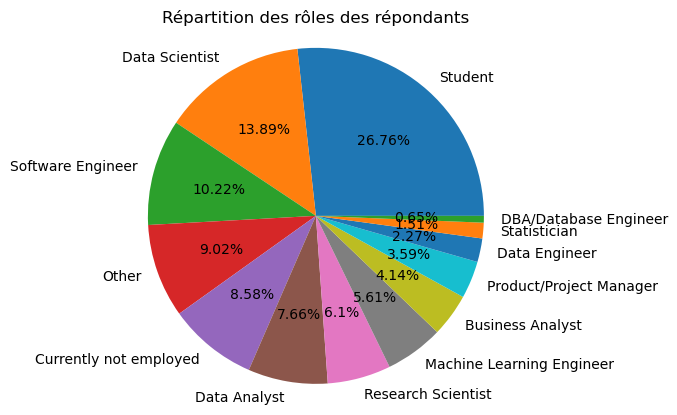

In [14]:
## Pie chart pour les rôles
role_counts = df['job_title'].value_counts() # Comptage des rôles

plt.pie(x = role_counts, labels=role_counts.index, autopct=lambda x: str(round(x, 2)) + '%')
plt.title("Répartition des rôles des répondants")
plt.axis('equal')  # Pour garder un cercle
plt.show()

2. Environnements de développement les plus utilisés par profil (métiers ciblés)

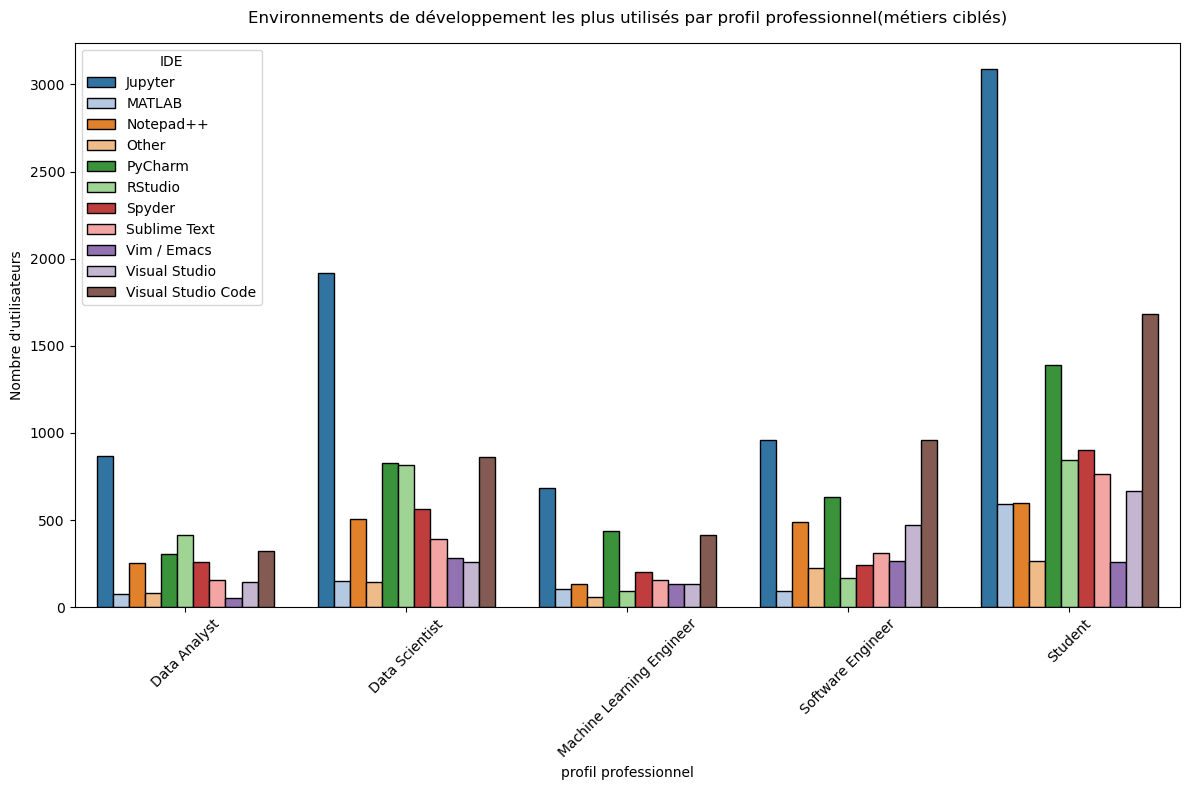

In [15]:
# Nettoyer et transformer la colonne IDE
dfnew = df[["job_title", "IDE"]].copy()
dfnew['IDE'] = dfnew['IDE'].str.replace(r'\(.*?\)', '', regex=True).str.split(',')
dfnew = dfnew.explode('IDE')
dfnew['IDE'] = dfnew['IDE'].str.strip()

#  Filtrer pour garder seulement les métiers pertinents
top_jobs = ['Data Analyst', 'Machine Learning Engineer', 'Data Scientist', 'Software Engineer', 'Student']
df_filtered = dfnew[dfnew['job_title'].isin(top_jobs)].copy()

#  Compter les occurrences
count_data = df_filtered.groupby(['job_title', 'IDE']).size().reset_index(name='counts')

# Visualisation
plt.figure(figsize=(12, 8))
sns.barplot(
    data=count_data,
    y='counts',
    x='job_title',
    hue='IDE',
    palette = "tab20" ,
    edgecolor='black',
    linewidth=1
)
plt.title('Environnements de développement les plus utilisés par profil professionnel(métiers ciblés)', y=1.02)
plt.xlabel('profil professionnel')
plt.xticks(rotation=45)
plt.ylabel('Nombre d\'utilisateurs')
plt.tight_layout()
plt.tight_layout()
plt.show()

3. Outils de DataVisualisation les plus utilisés par profils


C:\Users\clifo\AppData\Local\Temp\ipykernel_29028\3353402816.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='Data_viz_libraries',
C:\Users\clifo\AppData\Local\Temp\ipykernel_29028\3353402816.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='Data_viz_libraries',
C:\Users\clifo\AppData\Local\Temp\ipykernel_29028\3353402816.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='Data_viz_libraries',
C:\Users\clifo\AppData\Local\Temp\ipykernel_29028\3353402816.py:30: FutureWarning: 

Passing `palett

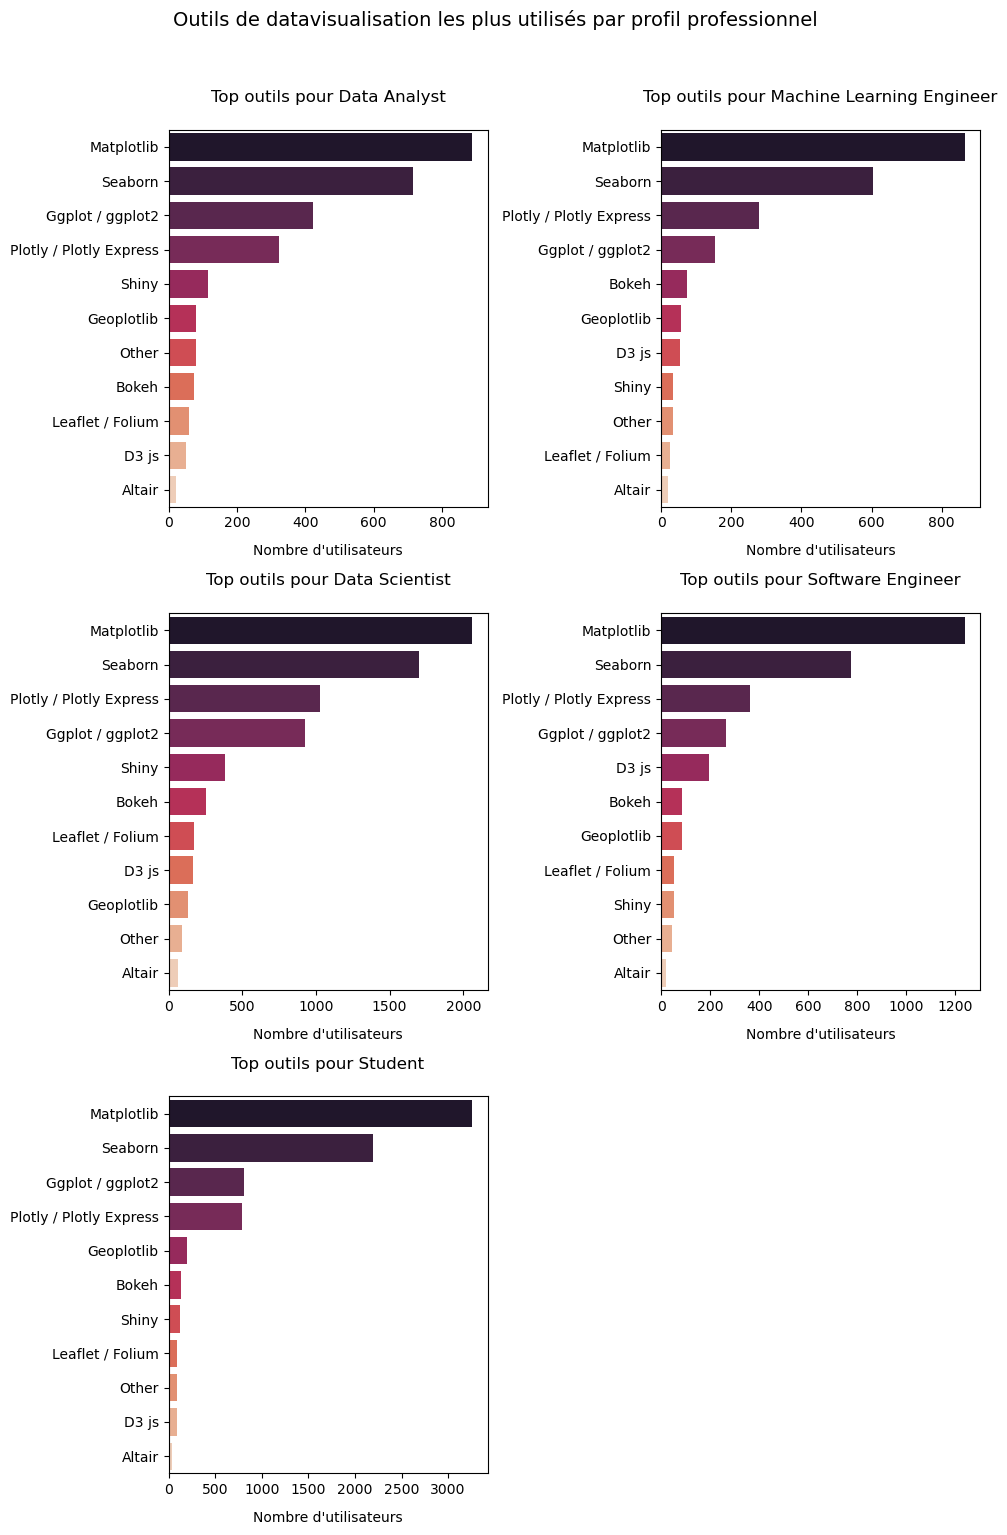

In [16]:
# Fonction pour nettoyer et compter les données d'une colonne à choix multiples
def clean_data_viz(data):

    # Nettoyage
    cleaned_data = (
        data.dropna()                  # Supprime les valeurs manquantes
        .str.split(',')                # Sépare par virgules
        .explode()                     # Crée une ligne par outil
        .str.strip()                   # Supprime les espaces
        .loc[lambda x: x != '']        # Filtre les chaînes vides
    )

    # Comptage et formatage du résultat
    result = cleaned_data.value_counts().reset_index()

    return result
clean_data_viz(df.Data_viz_libraries)


top_jobs = ['Data Analyst', 'Machine Learning Engineer','Data Scientist','Software Engineer', 'Student']

plt.figure(figsize=(10, 15))
i=1
for job in top_jobs:
    plt.subplot(3, 2, i)
    i+=1
    job_df = clean_data_viz(df[df['job_title'] == job]['Data_viz_libraries'])

    # Visualisation avec des noms de colonnes explicites
    sns.barplot(x='count', y='Data_viz_libraries',
                data=job_df,
                palette='rocket',
                ) # Garde l'ordre du tri

    plt.title(f'Top outils pour {job}', pad=20)
    plt.xlabel('Nombre d\'utilisateurs', labelpad=10)
    plt.ylabel('')
    plt.tight_layout()

plt.suptitle('Outils de datavisualisation les plus utilisés par profil professionnel',
             y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

4. Graphique d'utilisation des outils par pays pour les Data Analysts et Scientists

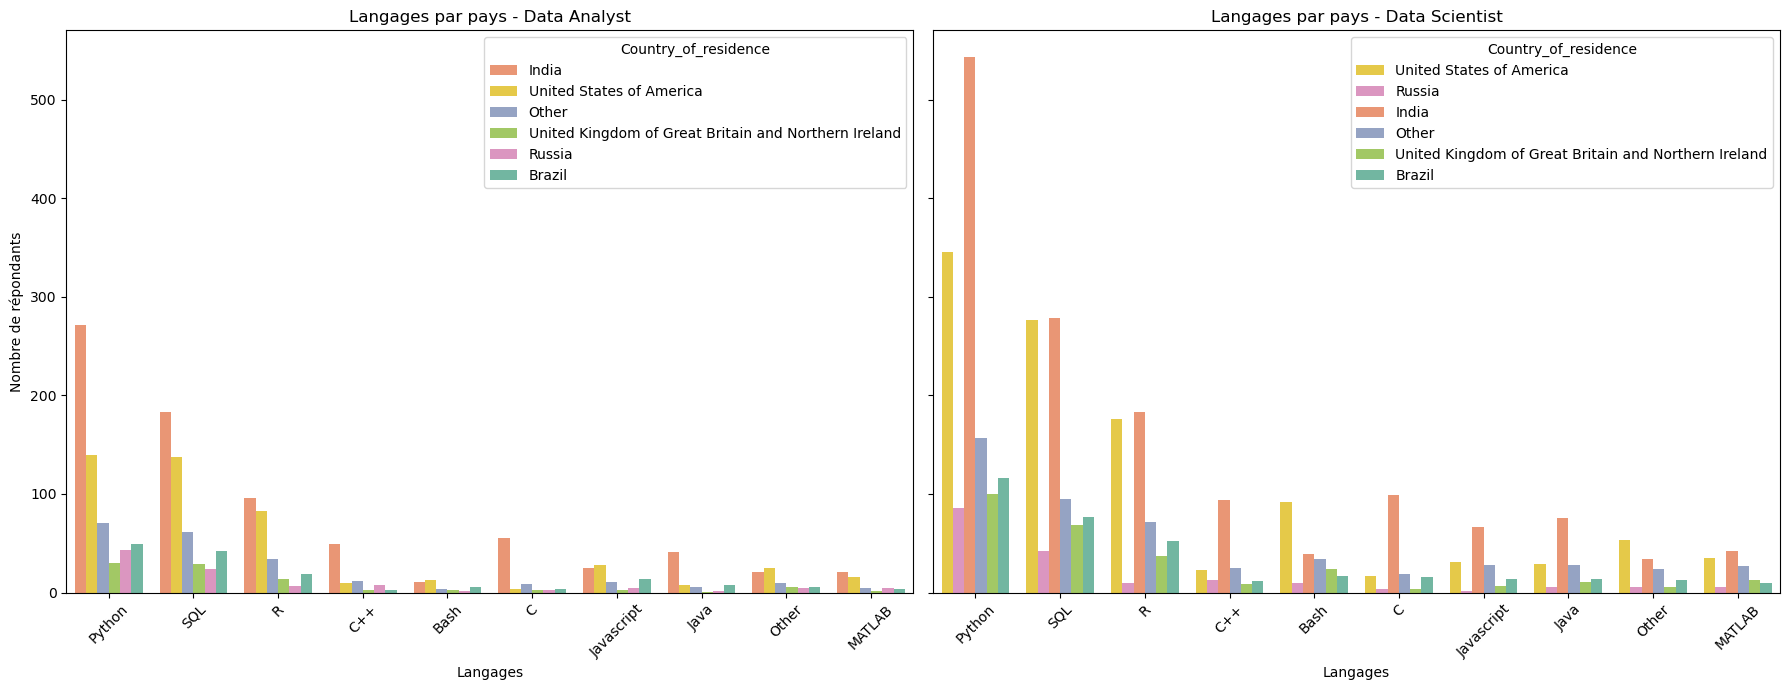

In [17]:
# Nettoyage et préparation
df = df[df["programming_languages"].notna()].copy()
df["programming_languages"] = df["programming_languages"].apply(
    lambda x: [lang.strip() for lang in x.split(",")] if isinstance(x, str) else []
)

df = df.reset_index(drop=True)
df_filtered = df[df["job_title"].isin(["Data Analyst", "Data Scientist"])].copy()
df_filtered = df_filtered.reset_index(drop=True)
df_exploded = df_filtered.explode("programming_languages").reset_index(drop=True)
df_exploded = df_exploded[df_exploded["programming_languages"] != ""]

# Top pays
top_countries_analyst = df_exploded[df_exploded["job_title"]=="Data Analyst"]["Country_of_residence"].value_counts().nlargest(5).index
top_countries_scientist = df_exploded[df_exploded["job_title"]=="Data Scientist"]["Country_of_residence"].value_counts().nlargest(5).index
top_countries = list(set(top_countries_analyst).union(set(top_countries_scientist)))

df_top = df_exploded[df_exploded["Country_of_residence"].isin(top_countries)].copy()

# Créer une palette cohérente, pour avoir le même code couleur pour les pays
unique_countries = sorted(df_top["Country_of_residence"].unique())
palette_colors = sns.color_palette("Set2", len(unique_countries))
country_palette = dict(zip(unique_countries, palette_colors))

# Séparer les dataframes
df_analyst = df_top[df_top["job_title"] == "Data Analyst"]
df_scientist = df_top[df_top["job_title"] == "Data Scientist"]

top_langs = df_top["programming_languages"].value_counts().index[:10]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18,7), sharey=True)

sns.countplot(
    data=df_analyst,
    x="programming_languages",
    hue="Country_of_residence",
    order=top_langs,
    palette=country_palette,
    ax=axes[0]
)
axes[0].set_title("Langages par pays - Data Analyst")
axes[0].set_xlabel("Langages")
axes[0].set_ylabel("Nombre de répondants")
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(
    data=df_scientist,
    x="programming_languages",
    hue="Country_of_residence",
    order=top_langs,
    palette=country_palette,
    ax=axes[1]
)
axes[1].set_title("Langages par pays - Data Scientist")
axes[1].set_xlabel("Langages")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.legend
plt.show()

5. Expérience de codage selon le genre et le profil technique

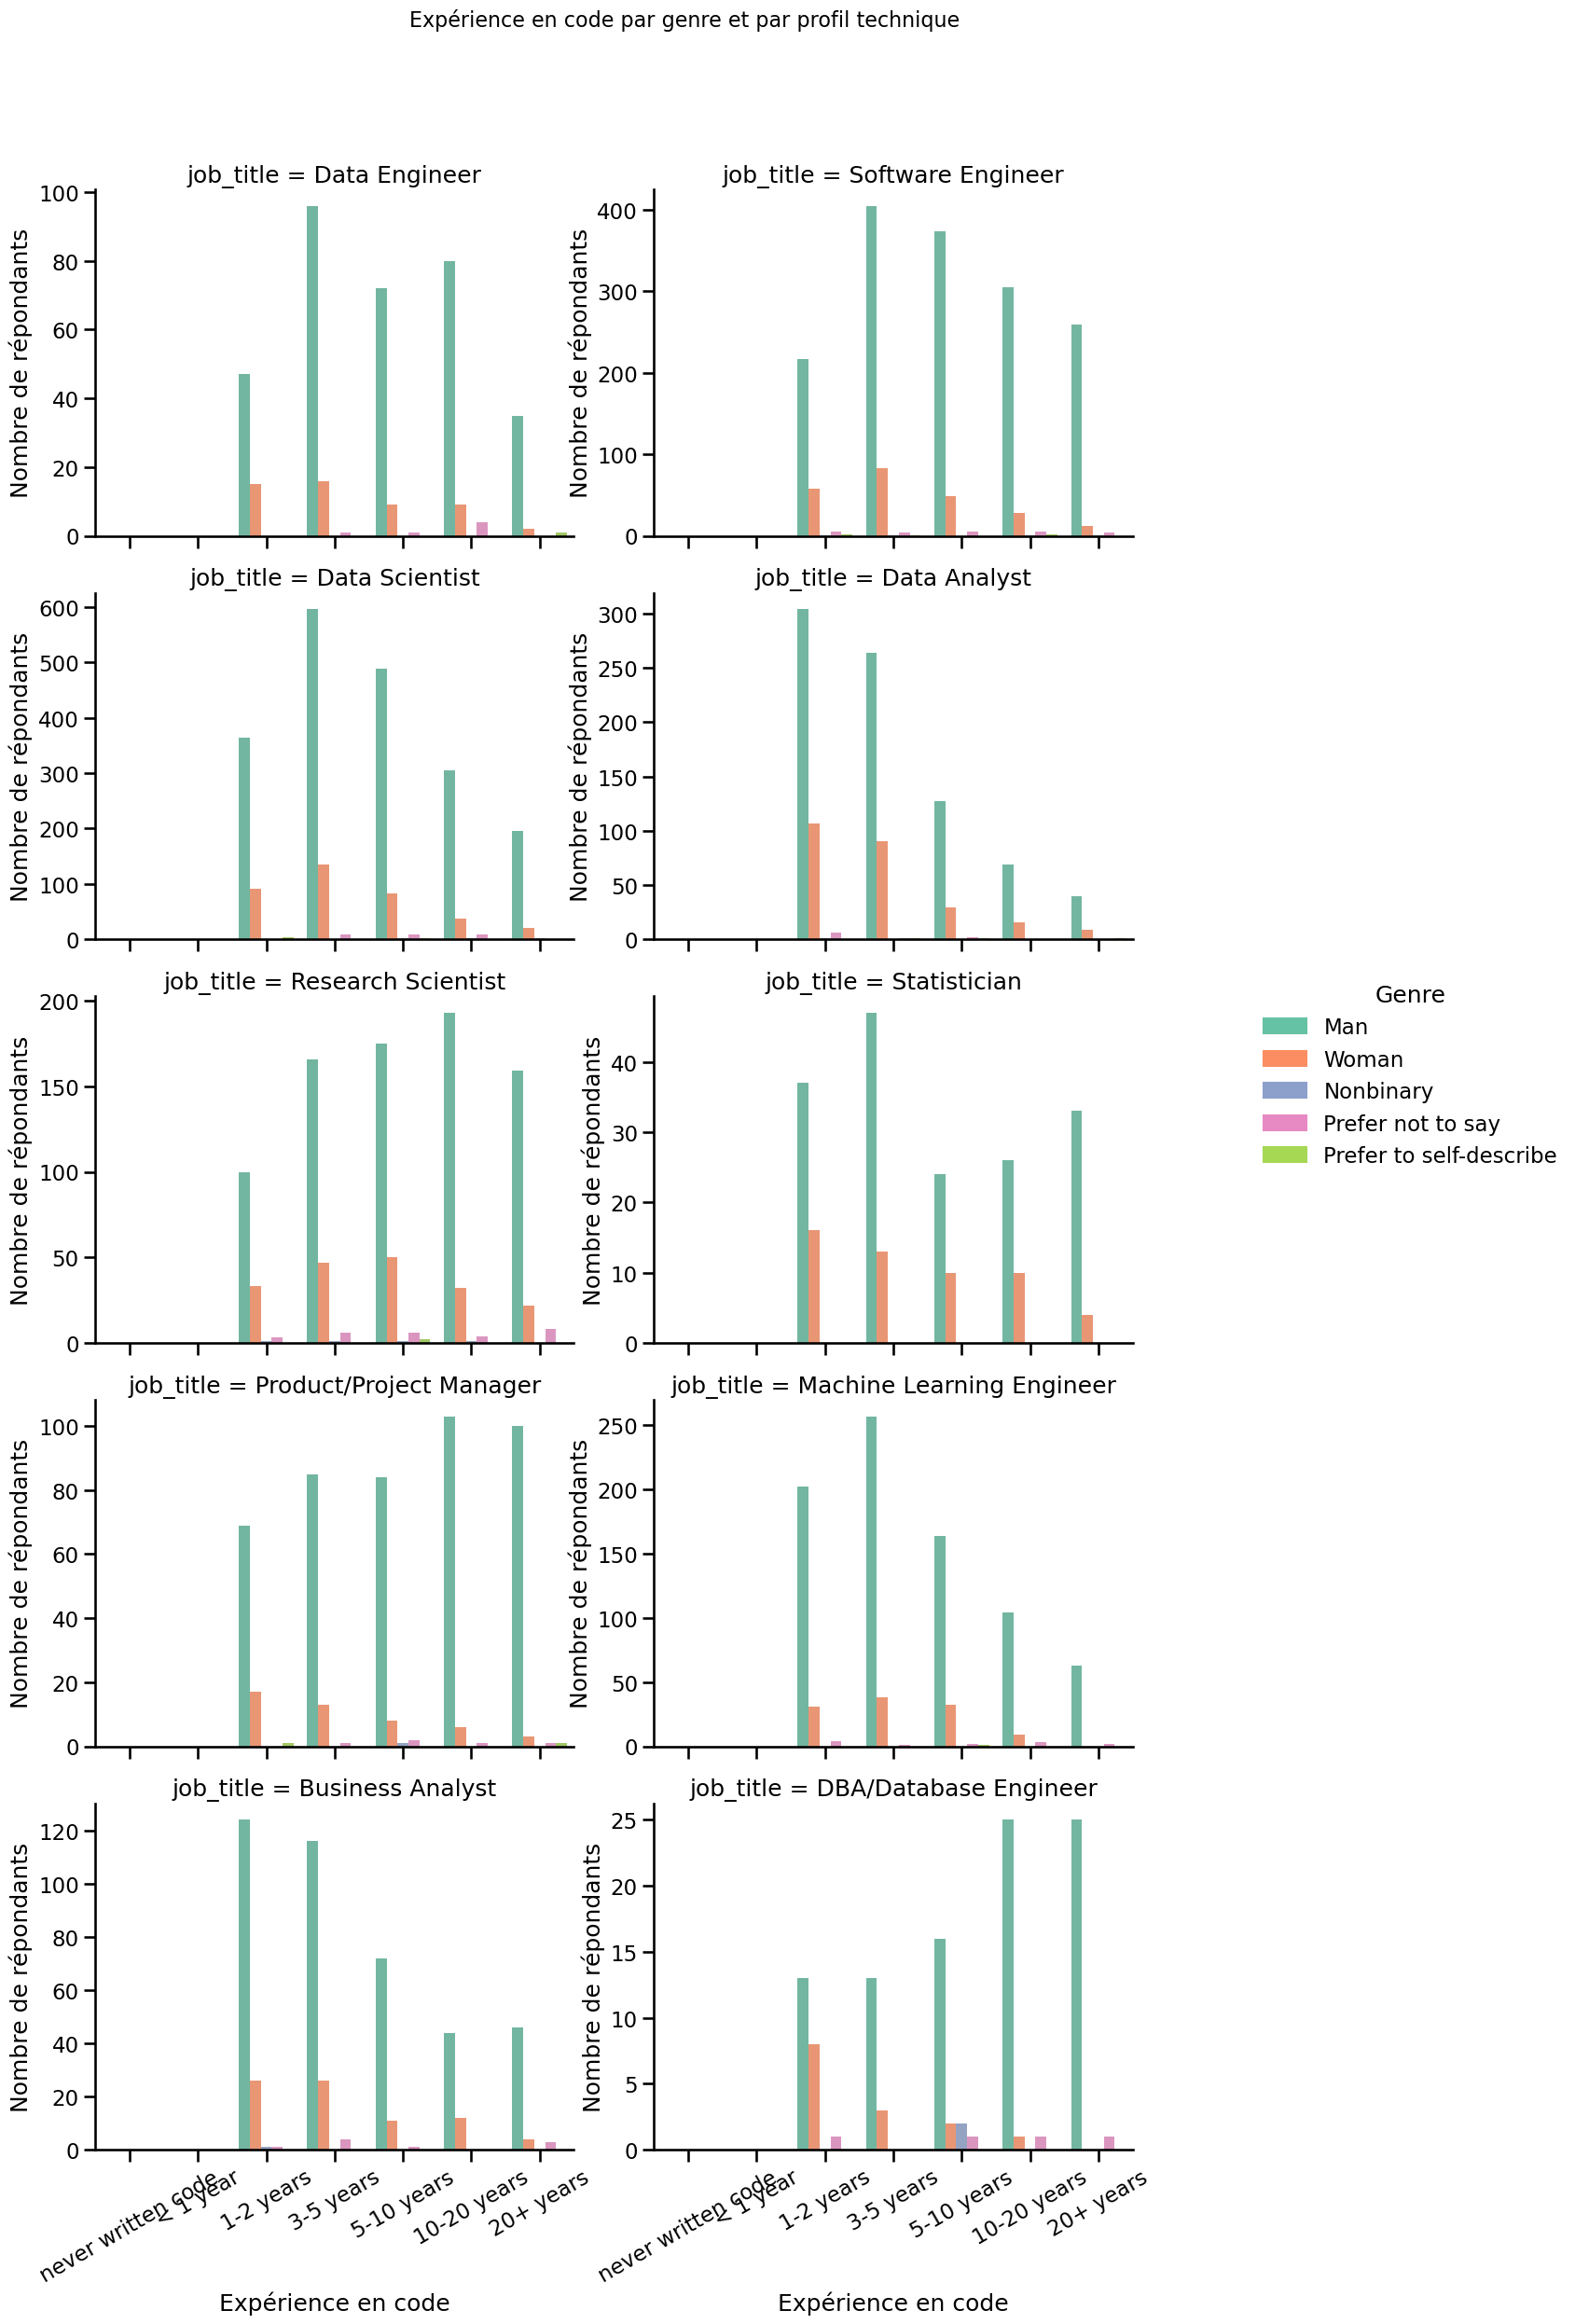

In [18]:
df_exp = df.dropna(subset=["Coding_experience", "Gender", "job_title"]).copy()

# Exclure certains profils
excluded_titles = ["Student", "Other", "Currently not employed"]
df_exp = df_exp[~df_exp["job_title"].isin(excluded_titles)]

# Ordre de l’expérience
experience_order = [
    "never written code",
    "< 1 year",
    "1-2 years",
    "3-5 years",
    "5-10 years",
    "10-20 years",
    "20+ years"
]

# Convertir en catégorie ordonnée
df_exp["Coding_experience"] = pd.Categorical(
    df_exp["Coding_experience"],
    categories=experience_order,
    ordered=True
)

# Contexte lisible
sns.set_context("talk")

palette = sns.color_palette("Set2")
genders = df_exp["Gender"].unique()

# Construire un dictionnaire genre -> couleur, selon l’ordre du tri
color_map = dict(zip(genders, palette[:len(genders)]))

# Plot sans légende automatique
g = sns.catplot(
    data=df_exp,
    x="Coding_experience",
    hue="Gender",
    col="job_title",
    kind="count",
    height=5,
    aspect=1.5,
    palette=color_map,
    col_wrap=2,
    sharey=False,
    legend=False
)

for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=30)
    ax.set_xlabel("Expérience en code")
    ax.set_ylabel("Nombre de répondants")

g.fig.subplots_adjust(top=0.88, right=0.82)

g.fig.text(0.5, 0.95, "Expérience en code par genre et par profil technique",
           ha='center', fontsize=16)

# Création manuelle des patches de légende
from matplotlib.patches import Patch
legend_handles = [Patch(color=color_map[gender], label=gender) for gender in genders]

g.fig.legend(
    handles=legend_handles,
    title="Genre",
    loc='center left',
    bbox_to_anchor=(0.9, 0.5),
    frameon=False
)

plt.show()


6. Utilisation des ML Frameworks selon les métiers


In [19]:
# Nettoyage de la variable ML_frameworks
# Étape 1 à 4 : Séparation, retrait des espaces, casse uniforme

step1_3_cleaned = df['Ml_frameworks'].dropna().str.split(',').explode().str.strip()

framework_mapping = {
    'Tensorflow': 'TensorFlow',
    'Pytorch': 'PyTorch',
    'Xgboost': 'XGBoost',
    'Lightgbm': 'LightGBM',
    'Fast.Ai': 'Fastai',
    'Scikit-Learn': 'Scikit-learn',
    'H2O 3': 'H2O.ai'
}

step4_standardized = step1_3_cleaned.replace(framework_mapping)

df_frameworks_cleaned = pd.DataFrame({'Ml_Frameworks_Cleaned': step4_standardized})

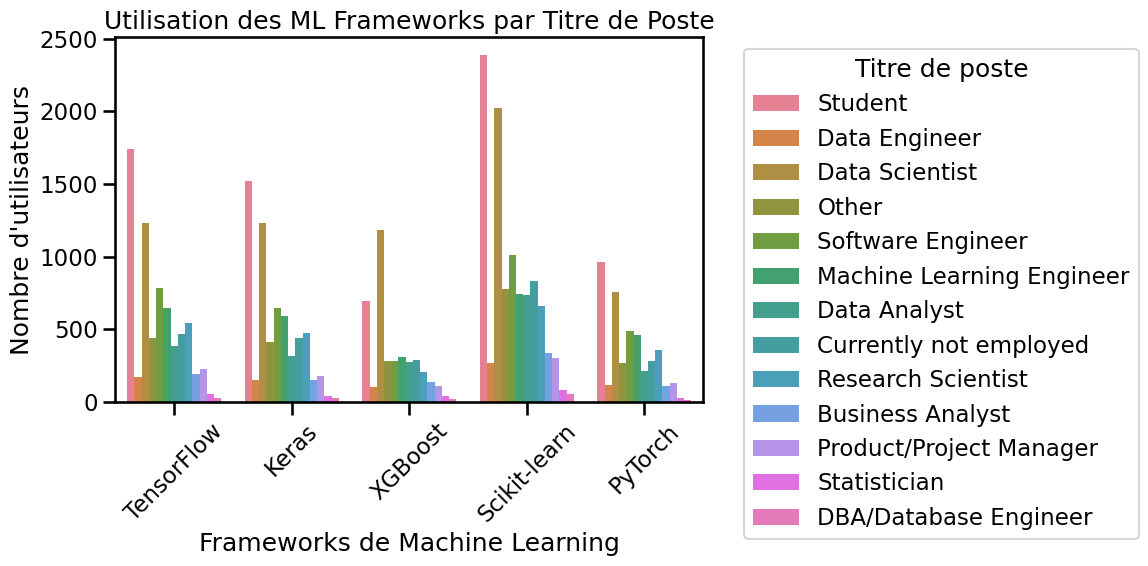

In [20]:
# Fusion des frameworks nettoyés avec les intitulés de poste
df_job_framework = pd.concat([
    df.loc[step4_standardized.index, 'job_title'],  # Aligner les lignes avec les frameworks
    step4_standardized.rename("Framework")
], axis=1).dropna()

# Pour alléger la visualisation, on peut se concentrer sur les 5 frameworks les plus fréquents
top_frameworks = df_job_framework['Framework'].value_counts().head(5).index
filtered_df = df_job_framework[df_job_framework['Framework'].isin(top_frameworks)]

# Création du graphique avec Seaborn
plt.figure(figsize=(12, 6))
sns.countplot(data=filtered_df, x='Framework', hue='job_title')
plt.title("Utilisation des ML Frameworks par Titre de Poste")
plt.xlabel("Frameworks de Machine Learning")
plt.ylabel("Nombre d'utilisateurs")
plt.xticks(rotation=45)
plt.legend(title='Titre de poste', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [21]:
# Sauvegarde du fichier
df.to_csv("groupe_datajobs_FinalDataviz.csv", index=False)

In [22]:
# ============================================================
# CLUSTERING (Notebook) — préparation + entraînement + export
# Objectif : faire le clustering dans le notebook, puis Streamlit
# ne fera que LIRE les résultats (rapide, stable, reproductible).
# ============================================================

import os
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

# ------------------------------------------------------------
# 1) Colonnes utilisées pour décrire un profil technique
# (⚠️ respecte exactement la casse : Coding_experience etc.)
# ------------------------------------------------------------
cluster_cols = [
    "job_title",
    "Coding_experience",
    "programming_languages",
    "IDE",
    "Hosted_notebook",
    "Computing_platform"
]

# ------------------------------------------------------------
# 2) Vérification anti-KeyError (on veut être sûr que les colonnes existent)
# ------------------------------------------------------------
missing = [c for c in cluster_cols if c not in df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes dans df : {missing}")

# ------------------------------------------------------------
# 3) Création df_clust (sans dropna !) : on garde toutes les lignes
# et on gère les valeurs manquantes proprement après.
# ------------------------------------------------------------
df_clust = df[cluster_cols].copy()

# ------------------------------------------------------------
# 4) Nettoyage des colonnes "listées" (valeurs séparées par virgules)
# Ex: "Python, SQL, R" -> on garde le 1er élément "Python" (simple et efficace)
# ------------------------------------------------------------
list_like_cols = ["programming_languages", "IDE", "Hosted_notebook", "Computing_platform"]

for col in list_like_cols:
    df_clust[col] = df_clust[col].apply(
        lambda x: x.split(",")[0].strip() if isinstance(x, str) else x
    )

# ------------------------------------------------------------
# 5) Fix définitif du problème "Categorical + Unknown"
# On force tout en texte avant fillna.
# -> plus d’erreur "Cannot setitem on a Categorical..."
# ------------------------------------------------------------
df_clust = df_clust.astype("string").fillna("Unknown")

# (Optionnel) Petite vérification
print("✅ df_clust prêt | lignes =", len(df_clust))
print("Valeurs manquantes restantes =", df_clust.isna().sum().sum())

# ------------------------------------------------------------
# 6) Pipeline de prétraitement + KMeans
# - SimpleImputer: au cas où (sécurité)
# - OneHotEncoder: convertit les catégories en colonnes 0/1
# - KMeans: clustering
# ------------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cluster_cols)
    ],
    remainder="drop"
)

n_clusters = 4
random_state = 42

model = Pipeline(steps=[
    ("prep", preprocessor),
    ("kmeans", KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto"))
])

# Entraînement
model.fit(df_clust)

# ------------------------------------------------------------
# 7) Ajouter le label de cluster au dataframe
# ------------------------------------------------------------
labels = model.named_steps["kmeans"].labels_
df_clusters = df_clust.copy()
df_clusters["Cluster"] = labels

print(df_clusters["Cluster"].value_counts().sort_index())

# ------------------------------------------------------------
# 8) Sauvegarde pour Streamlit (CSV)
# IMPORTANT : créer le dossier data s’il n’existe pas
# ------------------------------------------------------------
os.makedirs("data", exist_ok=True)
output_path = os.path.join("data", "clustered_profiles.csv")
df_clusters.to_csv(output_path, index=False)

print(f"✅ Fichier sauvegardé : {output_path}")

✅ df_clust prêt | lignes = 17702
Valeurs manquantes restantes = 0
Cluster
0    5611
1    4670
2    2748
3    4673
Name: count, dtype: int64
✅ Fichier sauvegardé : data\clustered_profiles.csv
